In [1]:
# Install yfinance
!pip install yfinance

**1.Problem Statement:**  Predict the next day's closing price of a stock using historical market data.

**Goal:** Build a machine learning model (Random Forest) that uses today's features (Open, High, Low, Volume) to forecast tomorrow's closing price.

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

**2. Dataset Loading and Preprocessing**

In [3]:
TICKER = "AAPL"

#Loading data from Jan 1 2021 till now
df = yf.download(TICKER, start="2021-01-01", end=pd.Timestamp.today().strftime('%Y-%m-%d'))

#dsiplay first 10 rows of dataset
print(f"{TICKER} dataset shape:", df.shape)
print(df.head(10))

[*********************100%***********************]  1 of 1 completed

AAPL dataset shape: (1283, 5)
Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2021-01-04  125.856712  129.941387  123.279474  129.853862  143301900
2021-01-05  127.412781  128.122747  124.903619  125.350996   97664900
2021-01-06  123.123856  127.451673  122.909895  124.213106  155088000
2021-01-07  127.325195  128.015707  124.349219  124.835490  109578200
2021-01-08  128.424225  128.988301  126.654191  128.793781  105158200
2021-01-11  125.438507  126.595835  124.971691  125.642748  100384500
2021-01-12  125.263466  126.129028  123.376731  124.971700   91951100
2021-01-13  127.296074  127.840695  124.961978  125.224554   88636800
2021-01-14  125.370445  127.403055  125.224555  127.208550   90221800
2021-01-15  123.649033  126.644465  123.512877  125.244001  111598500


Feature Engineering Explanation

we use it because it transform raw stock data into more informative inputs for the model. because without it the model random forest that i used would just see raw price and volumn, it won't know about the trends which will results in poor pridiction

In [4]:
#FEATURE ENGINEERING

#Lag features  -> helping model to see pattern
df['Close_Lag1'] = df['Close'].shift(1)
df['Close_Lag2'] = df['Close'].shift(2)

#moving averages  -> show the trend over last few days
df['MA5'] = df['Close'].rolling(5).mean()   #5 days
df['MA10'] = df['Close'].rolling(10).mean() #10 days

#price change and return -> helps model capture daily momentum
df['Price_Change'] = df['Close'] - df['Open']
df['Return'] = df['Close'].pct_change()

#Target variable: next day's close ->shifing Close column to next day because that exactly what we want to predict
df['Target'] = df['Close'].shift(-1)

#removing missing values
data = df.dropna()

# Features and target
features = ['Open', 'High', 'Low', 'Volume', 'Close_Lag1', 'Close_Lag2', 'MA5', 'MA10', 'Price_Change', 'Return']
X = data[features]
y = data['Target']

In [5]:
#TRAIN/TEST SPLIT   -> prevents data leakage, train on past, test on future
split_index = int(len(X)*0.8)
X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

# Scale features    -> ensures all features are on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 1018, Testing samples: 255


**3. Data Visualization before traning the model**

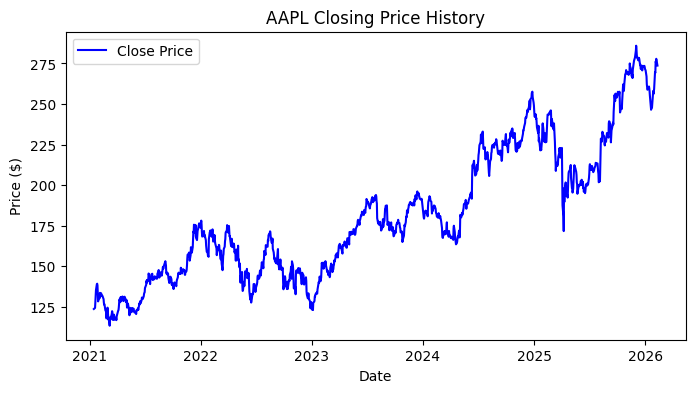

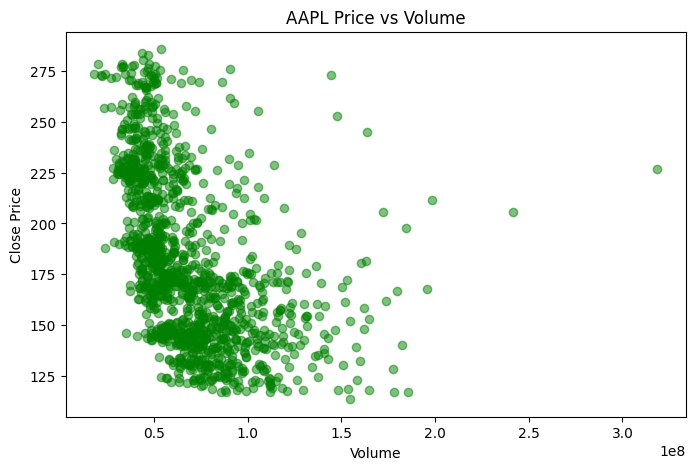

In [11]:
#plot historical Close prices
plt.figure(figsize=(8,4))
plt.plot(data.index, data['Close'], label='Close Price', color='blue')
plt.title(f'{TICKER} Closing Price History')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

#Scatter plot: Close vs Volume
plt.figure(figsize=(8,5))
plt.scatter(data['Volume'], data['Close'], alpha=0.5, color='green')
plt.title(f'{TICKER} Price vs Volume')
plt.xlabel('Volume')
plt.ylabel('Close Price')
plt.show()

**4. Model Training and Evaluation**

In [7]:
#MODEL TRAINING

model = LinearRegression()

# Train model
model.fit(X_train_scaled, y_train)

#Predict
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)


In [8]:
# MODEL EVALUATION

train_mae = mean_absolute_error(y_train, y_train_pred)    # mae -> diff b/w actual and pridicted price
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred)) #rmse -> similar to mae but penalize large errors
train_r2 = r2_score(y_train, y_train_pred)    #r2 -> shows how well model explains variance in data

test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("\nMODEL PERFORMANCE:")
print(f"Training R²: {train_r2:.4f}, MAE: ${train_mae:.2f}, RMSE: ${train_rmse:.2f}")
print(f"Testing R²: {test_r2:.4f}, MAE: ${test_mae:.2f}, RMSE: ${test_rmse:.2f}")


MODEL PERFORMANCE:
Training R²: 0.9929, MAE: $2.03, RMSE: $2.72
Testing R²: 0.9766, MAE: $2.82, RMSE: $4.29


**5. Result**

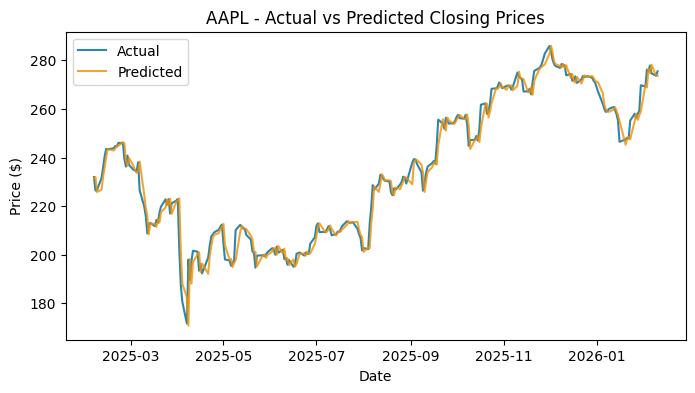

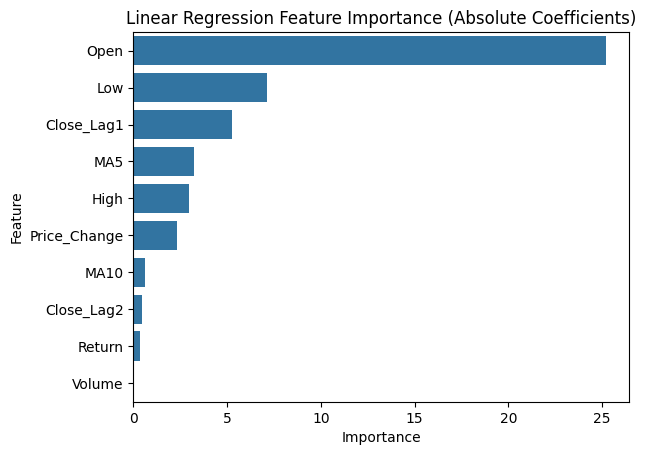

Last Closing Price: $273.68
Predicted Next Day Closing Price: $273.68


In [12]:
#Actual vs Predicted
plt.figure(figsize=(8,4))
plt.plot(data.index[split_index:], y_test, label='Actual', color='#2E86AB')
plt.plot(data.index[split_index:], y_test_pred, label='Predicted', color='#F18F01', alpha=0.8)
plt.title(f"{TICKER} - Actual vs Predicted Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

#Feature Importance for Linear Regression, coefficients indicate importance
feat_importance = pd.DataFrame({
    'Feature': features,
    'Importance': np.abs(model.coef_)
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feat_importance)
plt.title("Linear Regression Feature Importance (Absolute Coefficients)")
plt.show()

#Next Day Prediction
last_row = X.iloc[-1:]
last_scaled = scaler.transform(last_row)
next_day_price = model.predict(last_scaled)[0]
print(f"Last Closing Price: ${data['Close'].iloc[-1].item():.2f}")
print(f"Predicted Next Day Closing Price: ${next_day_price:.2f}")

**Final Result/Summary**

*   Model performed very well on the training data **R² = 0.9929**. It learned the patterns effectively.
*   On testing data the model accuracy is **R² = 0.9766** which means it generalizes well to unseen data.
*   The average prediction error was around 2–3 $ which is small compared to the actual stock price range.
*   The small difference between training and testing results indicates minimal overfitting.
*   Linear Regression with proper feature engineering successfully captured short-term stock price trends.